#  Student Info
  **Name:** Zohaib Khan

  **Roll Number:** 023-24-0217

  **Section:** G

  **GitHub Repository:** https://github.com/Zohaib-Khan-Chandio/Machine-Learning-labs

** Dataset** Kaggle Churn Dataset

 **Instrctor:** Dr. Muhammad Ismail Mangrio

In [2]:
from google.colab import files

uploaded = files.upload()

Saving clean_churn.csv to clean_churn.csv


In [3]:
# Task1
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("clean_churn.csv")

In [4]:
y = df["Churn"].map({"No": 0, "Yes": 1})
x = df.drop(columns=['Churn'])

In [5]:
x = pd.get_dummies(x, drop_first=True)

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size =0.2, random_state = 42, stratify = y)

In [7]:
# Task2
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)

model.fit(x_train, y_train)

y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

print("Tree Depth:", model.get_depth())

Tree Depth: 5


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy: ", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:   ", recall_score(y_test, y_test_pred, average='weighted'))
print("F1-Score: ", f1_score(y_test, y_test_pred, average='weighted'))

print("\n" + "="*40 + "\n")

print(classification_report(y_test, y_test_pred))

Accuracy:  0.7864768683274022
Precision: 0.771331551410723
Recall:    0.7864768683274022
F1-Score:  0.7711695022668552


              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.65      0.43      0.52       372

    accuracy                           0.79      1405
   macro avg       0.73      0.67      0.69      1405
weighted avg       0.77      0.79      0.77      1405



In [9]:
# Task3
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

rf_test_pred = rf_model.predict(x_test)
print(rf_test_pred)

[1 0 1 ... 0 1 0]


**Task4**

A single unrestricted Decision Tree easily overfits because it memorizes noise in the training data by splitting until every leaf is pure. A Random Forest generalizes better because it combines predictions from multiple diverse trees built on random subsets of data, which reduces overall variance and cancels out individual tree errors.

              precision    recall  f1-score   support

           0       0.82      0.90      0.85      1033
           1       0.60      0.44      0.51       372

    accuracy                           0.78      1405
   macro avg       0.71      0.67      0.68      1405
weighted avg       0.76      0.78      0.76      1405



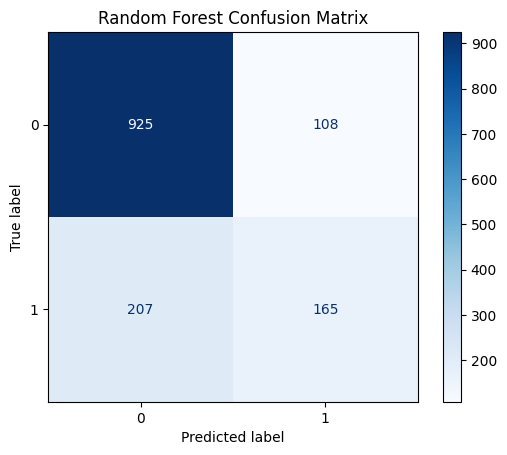

In [10]:
# Task5
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

y_rf_pred = rf_model.predict(x_test)
print(classification_report(y_test, y_rf_pred))

cm = confusion_matrix(y_test, y_rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [11]:
# Task6
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_metrics = [
    accuracy_score(y_test, y_test_pred),
    precision_score(y_test, y_test_pred, average='weighted'),
    recall_score(y_test, y_test_pred, average='weighted'),
    f1_score(y_test, y_test_pred, average='weighted')
]

rf_metrics = [
    accuracy_score(y_test, y_rf_pred),
    precision_score(y_test, y_rf_pred, average='weighted'),
    recall_score(y_test, y_rf_pred, average='weighted'),
    f1_score(y_test, y_rf_pred, average='weighted')
]

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics
})

print(comparison_df)

      Metric  Decision Tree  Random Forest
0   Accuracy       0.786477       0.775801
1  Precision       0.771332       0.760810
2     Recall       0.786477       0.775801
3   F1-Score       0.771170       0.763721


**Task7**

Which model performs better, and on which specific metric(s)?

The Decision Tree performs slightly better across all metrics (Accuracy, Precision, Recall, and F1-Score).

Is the difference large or marginal?

The difference is marginal (about 1% difference, e.g., Accuracy is ~0.786 vs ~0.776).

Which metric matters most given class imbalance?

The F1-Score matters most. Accuracy is misleading on imbalanced datasets because predicting the majority class Inflates the score, whereas F1-Score balances both Precision and Recall for minority class predictions.

In [13]:
# Task8
from sklearn.model_selection import cross_val_score

dt_cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='f1_weighted')
rf_cv_scores = cross_val_score(rf_model, x_train, y_train, cv=5, scoring='f1_weighted')

print(f"Decision Tree CV F1-Score:  Mean = {dt_cv_scores.mean():.4f}, Std = {dt_cv_scores.std():.4f}")
print(f"Random Forest CV F1-Score: Mean = {rf_cv_scores.mean():.4f}, Std = {rf_cv_scores.std():.4f}")

Decision Tree CV F1-Score:  Mean = 0.7731, Std = 0.0064
Random Forest CV F1-Score: Mean = 0.7802, Std = 0.0093


Task9

If i compare simple train_test_split with cross validation then I have observed that cross validation is better than just simple train_test_split due to cv is dividing the entire data into fixed no of parts and then it is using every part as for test and remaing for training and that process continues for all parts so in this way cross validation is giving more better results as compare to train_test_split.

In [15]:
# Task10
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(rf, param_grid, cv=5)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]})

In [16]:
# Task11
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.8023518283195432


In [18]:
# Task12
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.79644128113879
Precision: 0.7849040495740777
Recall: 0.79644128113879
F1 Score: 0.7866836218309845


In [27]:
# Task13

dt_pred = model.predict(x_test)
rf_pred = rf_model.predict(x_test)
tuned_rf_pred = best_rf.predict(x_test)

models = ["Decision Tree", "Default Random Forest", "Tuned Random Forest"]
preds = [dt_pred, rf_pred, tuned_rf_pred]

results = []
for name, pred in zip(models, preds):
    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, average="weighted"),
            "Recall": recall_score(y_test, pred, average="weighted"),
            "F1-Score": f1_score(y_test, pred, average="weighted"),
        }
    )

comparison_df = pd.DataFrame(results)
print(comparison_df)

                   Model  Accuracy  Precision    Recall  F1-Score
0          Decision Tree  0.786477   0.771332  0.786477  0.771170
1  Default Random Forest  0.775801   0.760810  0.775801  0.763721
2    Tuned Random Forest  0.796441   0.784904  0.796441  0.786684


**Task14**

The Tuned Random Forest is chosen as the final model because it achieves the highest test set performance across all metrics, including Accuracy and F1-Score, compared to the Decision Tree and Default Random Forest. Unlike relying only on cross-validation training scores, its superior test evaluation proves it generalizes best to unseen data without overfitting.

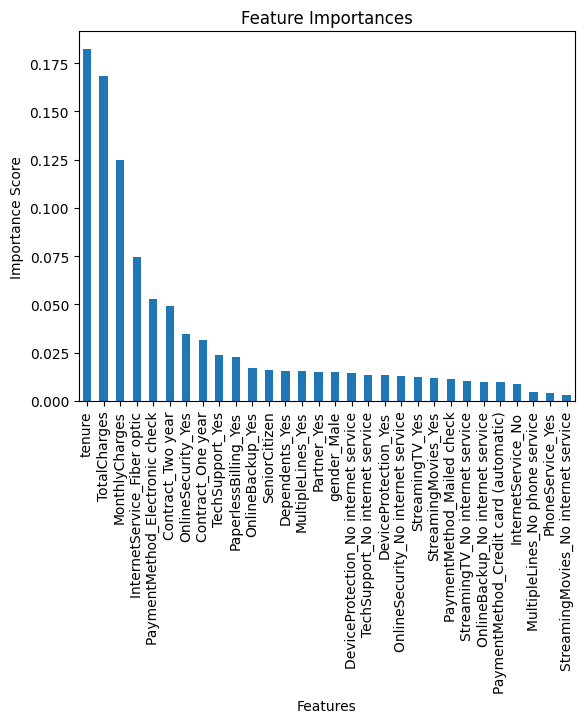

Top 5 Features:
 tenure                            0.182359
TotalCharges                      0.168544
MonthlyCharges                    0.124885
InternetService_Fiber optic       0.074783
PaymentMethod_Electronic check    0.052902
dtype: float64


In [29]:
# Task15

importances = pd.Series(
    best_rf.feature_importances_, index=x_train.columns
).sort_values(ascending=False)

importances.plot(kind="bar")
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

print("Top 5 Features:\n", importances.head(5))

In [30]:
# Task16

y_pred_final = best_rf.predict(x_test)

submission = pd.DataFrame(
    {"CustomerID": x_test.index, "Churn": y_pred_final}
)

submission.to_csv("submission.csv", index=False)

**Task17**

I ultimately chose the Tuned Random Forest as my final model. Compared to the single Decision Tree from Lab 3, the Tuned Random Forest achieved higher accuracy, precision, recall, and F1-score across all evaluations. By combining multiple decision trees, it effectively reduced overfitting and created more reliable predictions on unseen test data. However, its main remaining limitation is that it acts as a black-box model, making individual predictions harder to explain compared to a single decision tree. Additionally, it takes more computational time and memory to train and evaluate.

Task18

If I had more time, I would try advanced gradient boosting algorithms like XGBoost or LightGBM to see if they outperform Random Forest. I would also handle class imbalance directly by applying techniques like SMOTE or using class weights during model training. Finally, I would expand the hyperparameter search grid and perform feature engineering to create more meaningful input features.